# Reproduce the paper figures and quoted numerical values

This is the lightweight reproduction path. It reads the frozen per-realization data in `data/raw/`, regenerates the five manuscript figures, and prints the canonical numerical record. It does not rerun particle simulations.

In [1]:
from pathlib import Path
import json, subprocess, sys
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
print('Repository root:', ROOT)

# Preflight check for the lightweight reproduction path.
required = [
    ROOT/'scripts/make_paper_figures.py',
    ROOT/'data/results/phase3B_analysis_summary.json',
    ROOT/'data/results/paper_numbers.json',
    ROOT/'figures/source/B4_intrinsic_hierarchy_sigma.png',
    ROOT/'figures/source/B4_intrinsic_hierarchy_source.png',
    ROOT/'figures/source/B4_intrinsic_hierarchy_scores.png',
    ROOT/'figures/source/B4_intrinsic_hierarchy_rollout.png',
]
missing = [p.relative_to(ROOT) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError(
        'The extracted repository is incomplete. Missing:\n  - ' +
        '\n  - '.join(map(str, missing)) +
        '\nRe-extract the ZIP into a new empty directory rather than merging with an older copy.'
    )
optional_model = ROOT/'data/results/intrinsic_model_b_summary.json'
if not optional_model.exists():
    print('Note: data/results/intrinsic_model_b_summary.json is absent; '
          'the figure script will use the identical frozen model record in paper_numbers.json.')
else:
    print('Preflight check passed.')


Repository root: /mnt/data/work_release_v3/LagrangianEllipsoid_Corrected_Release_v3/2_github_repository
Preflight check passed.


In [2]:
proc = subprocess.run(
    [sys.executable, str(ROOT/'scripts/make_paper_figures.py')],
    cwd=ROOT, text=True, capture_output=True
)
if proc.stdout:
    print(proc.stdout)
if proc.returncode != 0:
    if proc.stderr:
        print(proc.stderr, file=sys.stderr)
    raise RuntimeError(f'Figure generation failed with exit code {proc.returncode}.')
print('Main figures regenerated.')


Generated final figures and paper_numbers.json

Main figures regenerated.


In [3]:
numbers = json.loads((ROOT/'data/results/paper_numbers.json').read_text())
for section in ['production','saturation','balance','model']:
    print(f'\n[{section}]')
    print(json.dumps(numbers[section], indent=2))


[production]
{
  "zeta": 0.3333333333333333,
  "Kmax": 192,
  "N": 1000,
  "n_realizations": 24,
  "r0_over_uv": 1.0,
  "train": 16,
  "test": 8
}

[saturation]
{
  "slope_3_8_MEE": 0.02806836772220207,
  "slope_3_8_MEE_sem": 0.16087942358081445,
  "slope_3_8_mass": 0.06982168606927126,
  "slope_3_8_mass_sem": 0.1828302001750003,
  "mean_sigma_MEE": 0.9098916483672186,
  "mean_sigma_mass": 1.0696040473122543,
  "delta_sigma": 0.15971239894503572,
  "delta_rho": 0.3379821485542885,
  "W1_MEE": 0.12680507569350333,
  "W1_mass": 0.24926323833365074
}

[balance]
{
  "n": 24,
  "delta": 0.1,
  "q_E_mean": 0.35191460246438694,
  "q_E_sem": 0.034366425131099686,
  "q_LS_mean": 0.033660010606818724,
  "q_LS_sem": 0.03442331707291479,
  "R_total_mean": -0.39372711354075784,
  "R_total_sem": 0.03529962904417463,
  "R_gradient_mean": -0.31825459185756827,
  "R_gradient_sem": 0.02879567538612566,
  "R_envelope_mean": -0.07547252168318959,
  "R_envelope_sem": 0.026812266719859177,
  "R_mass_E_mean

fig01_methodology.png


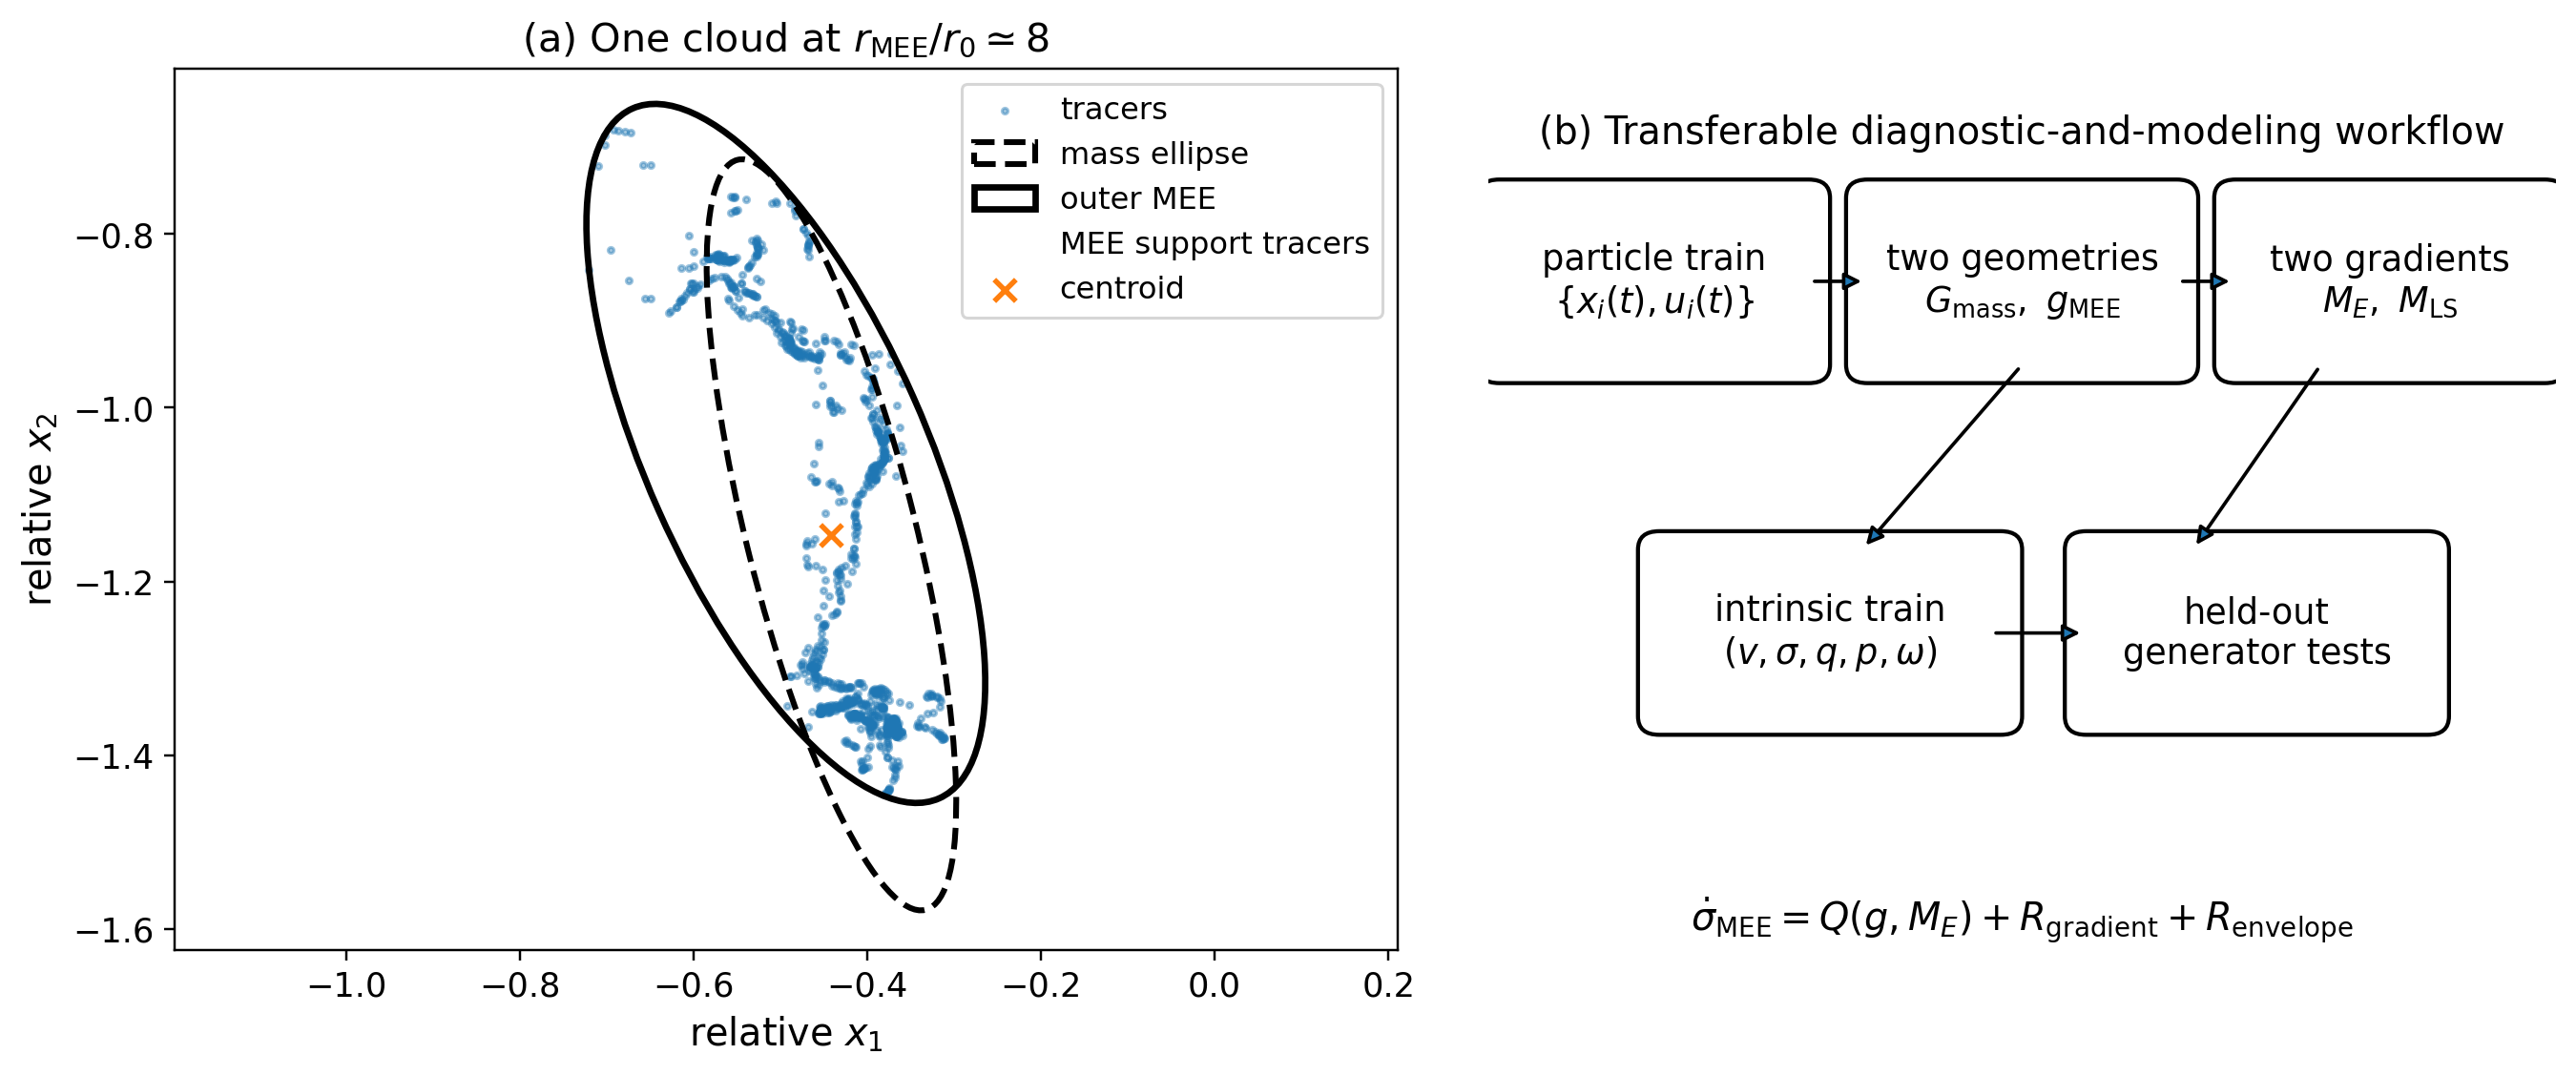

fig02_saturation.png


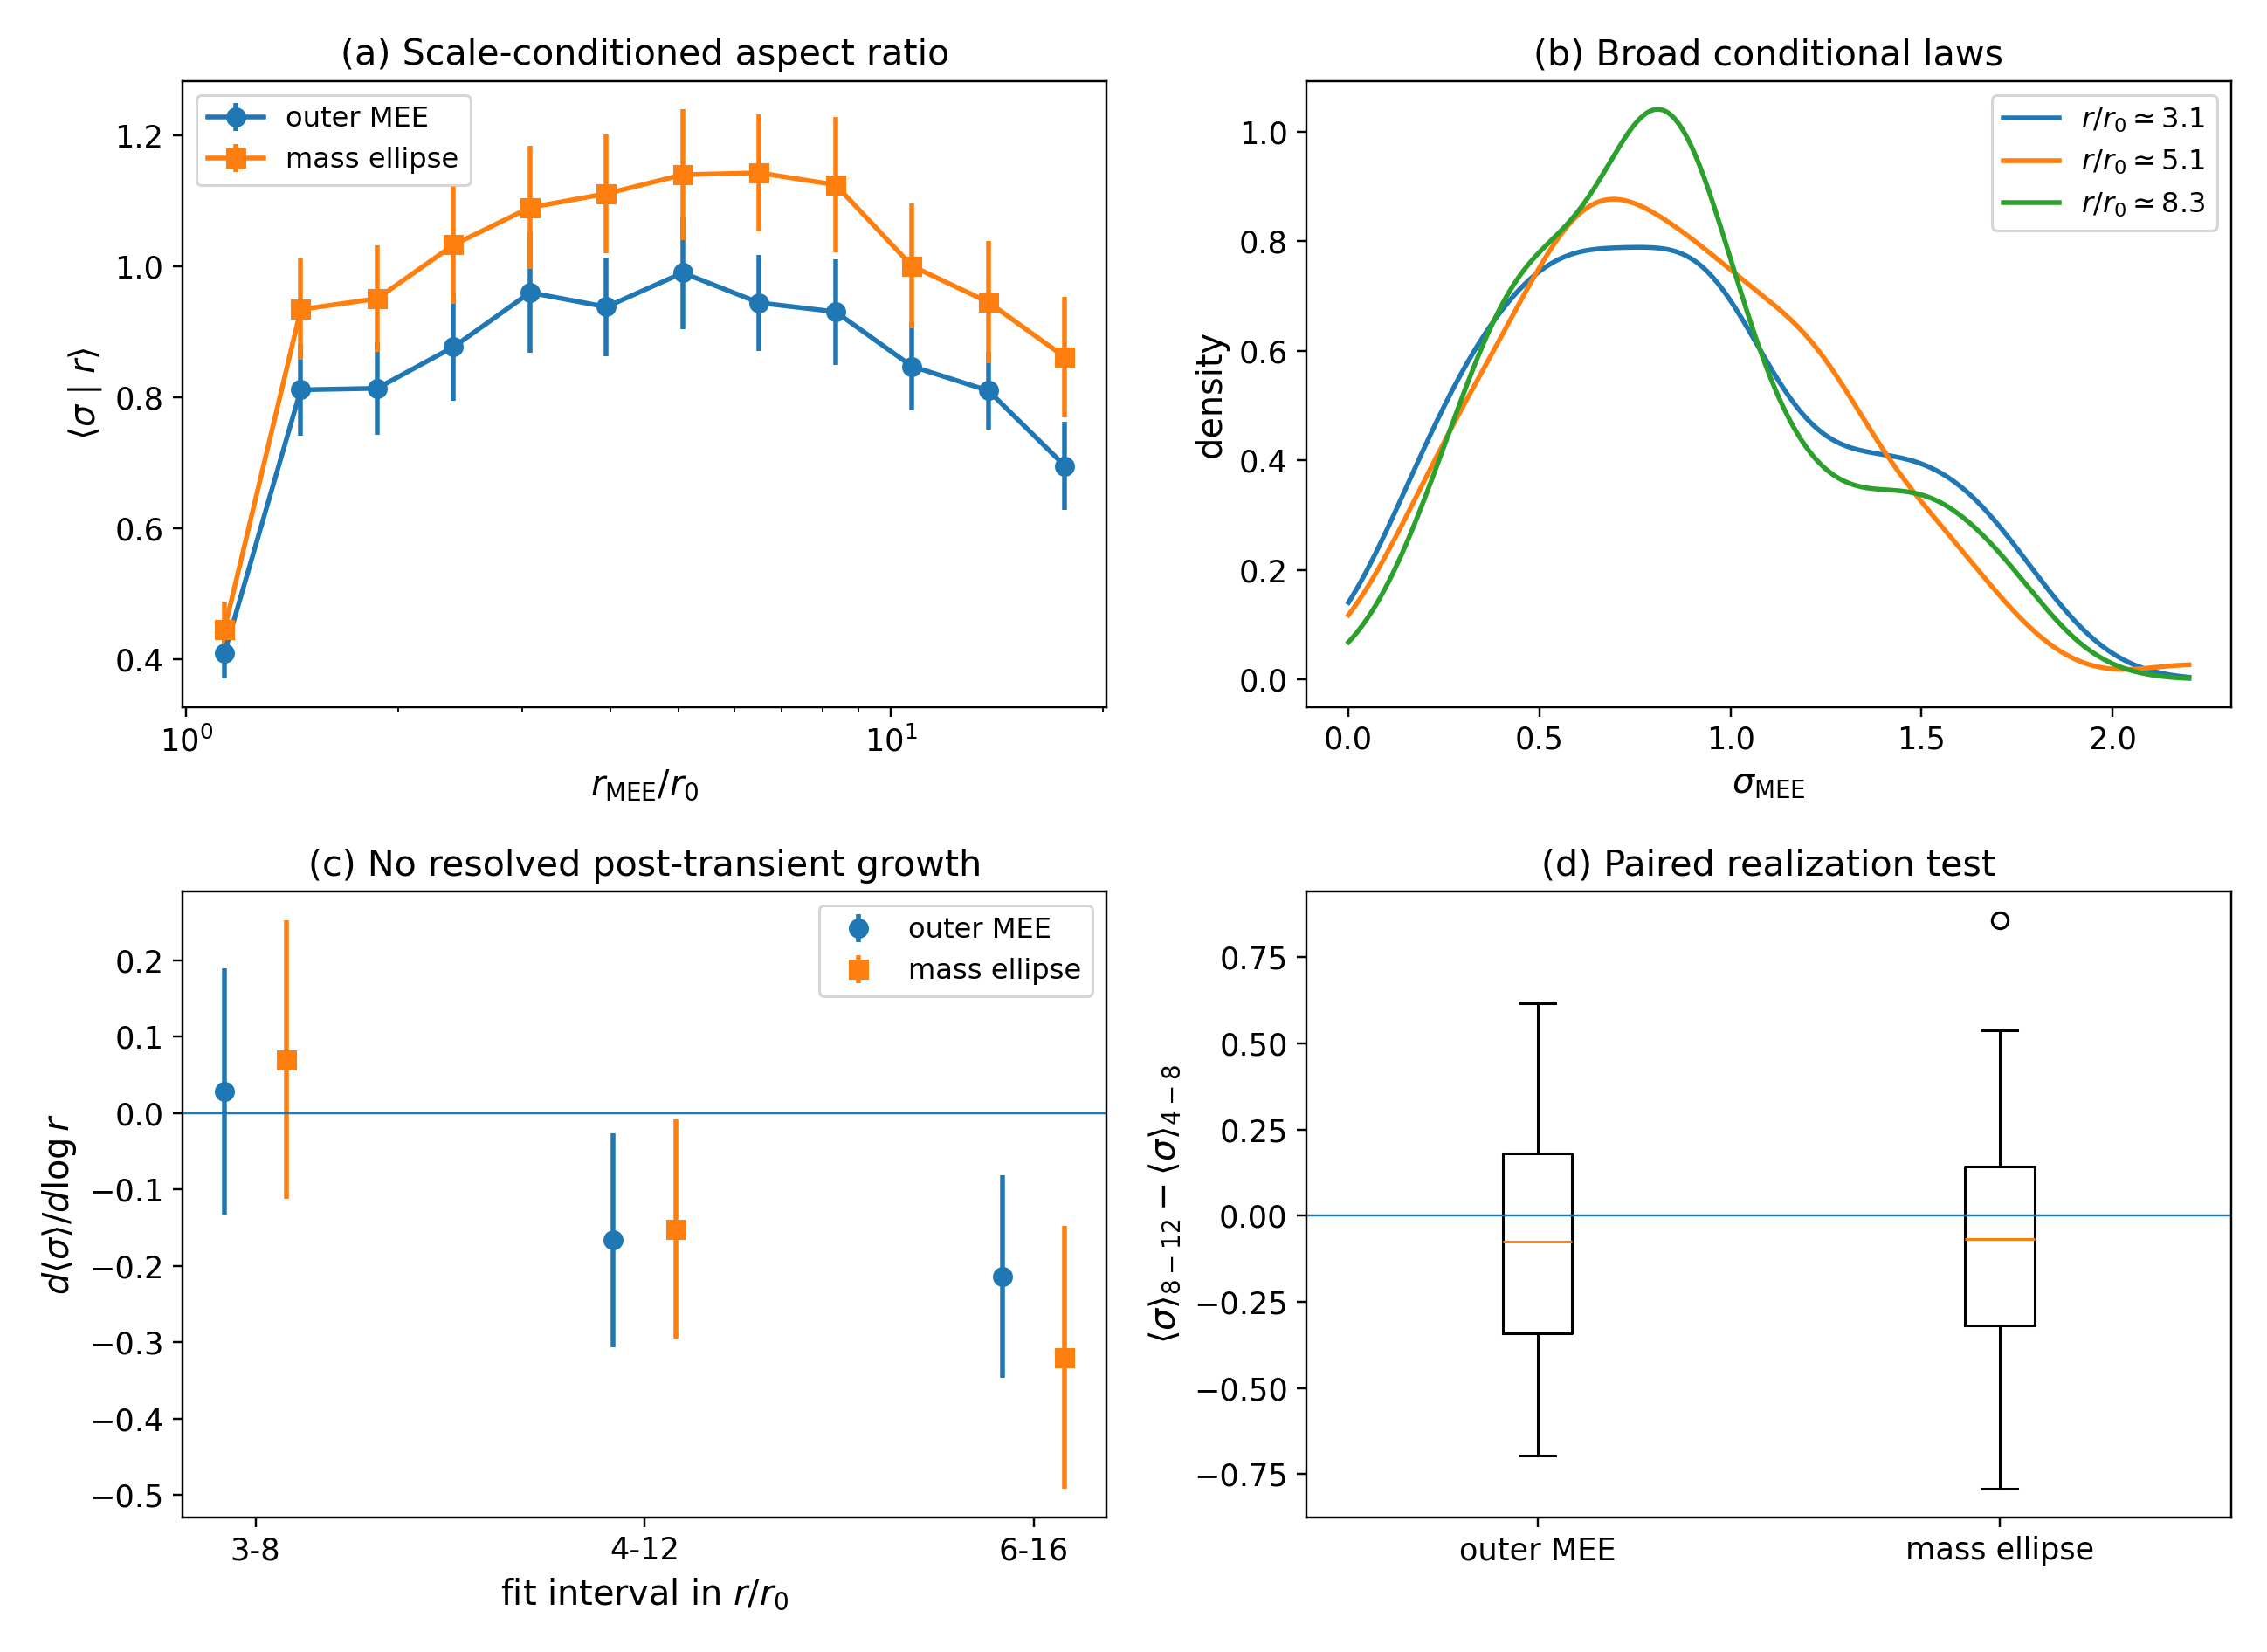

fig03_bulk_envelope.png


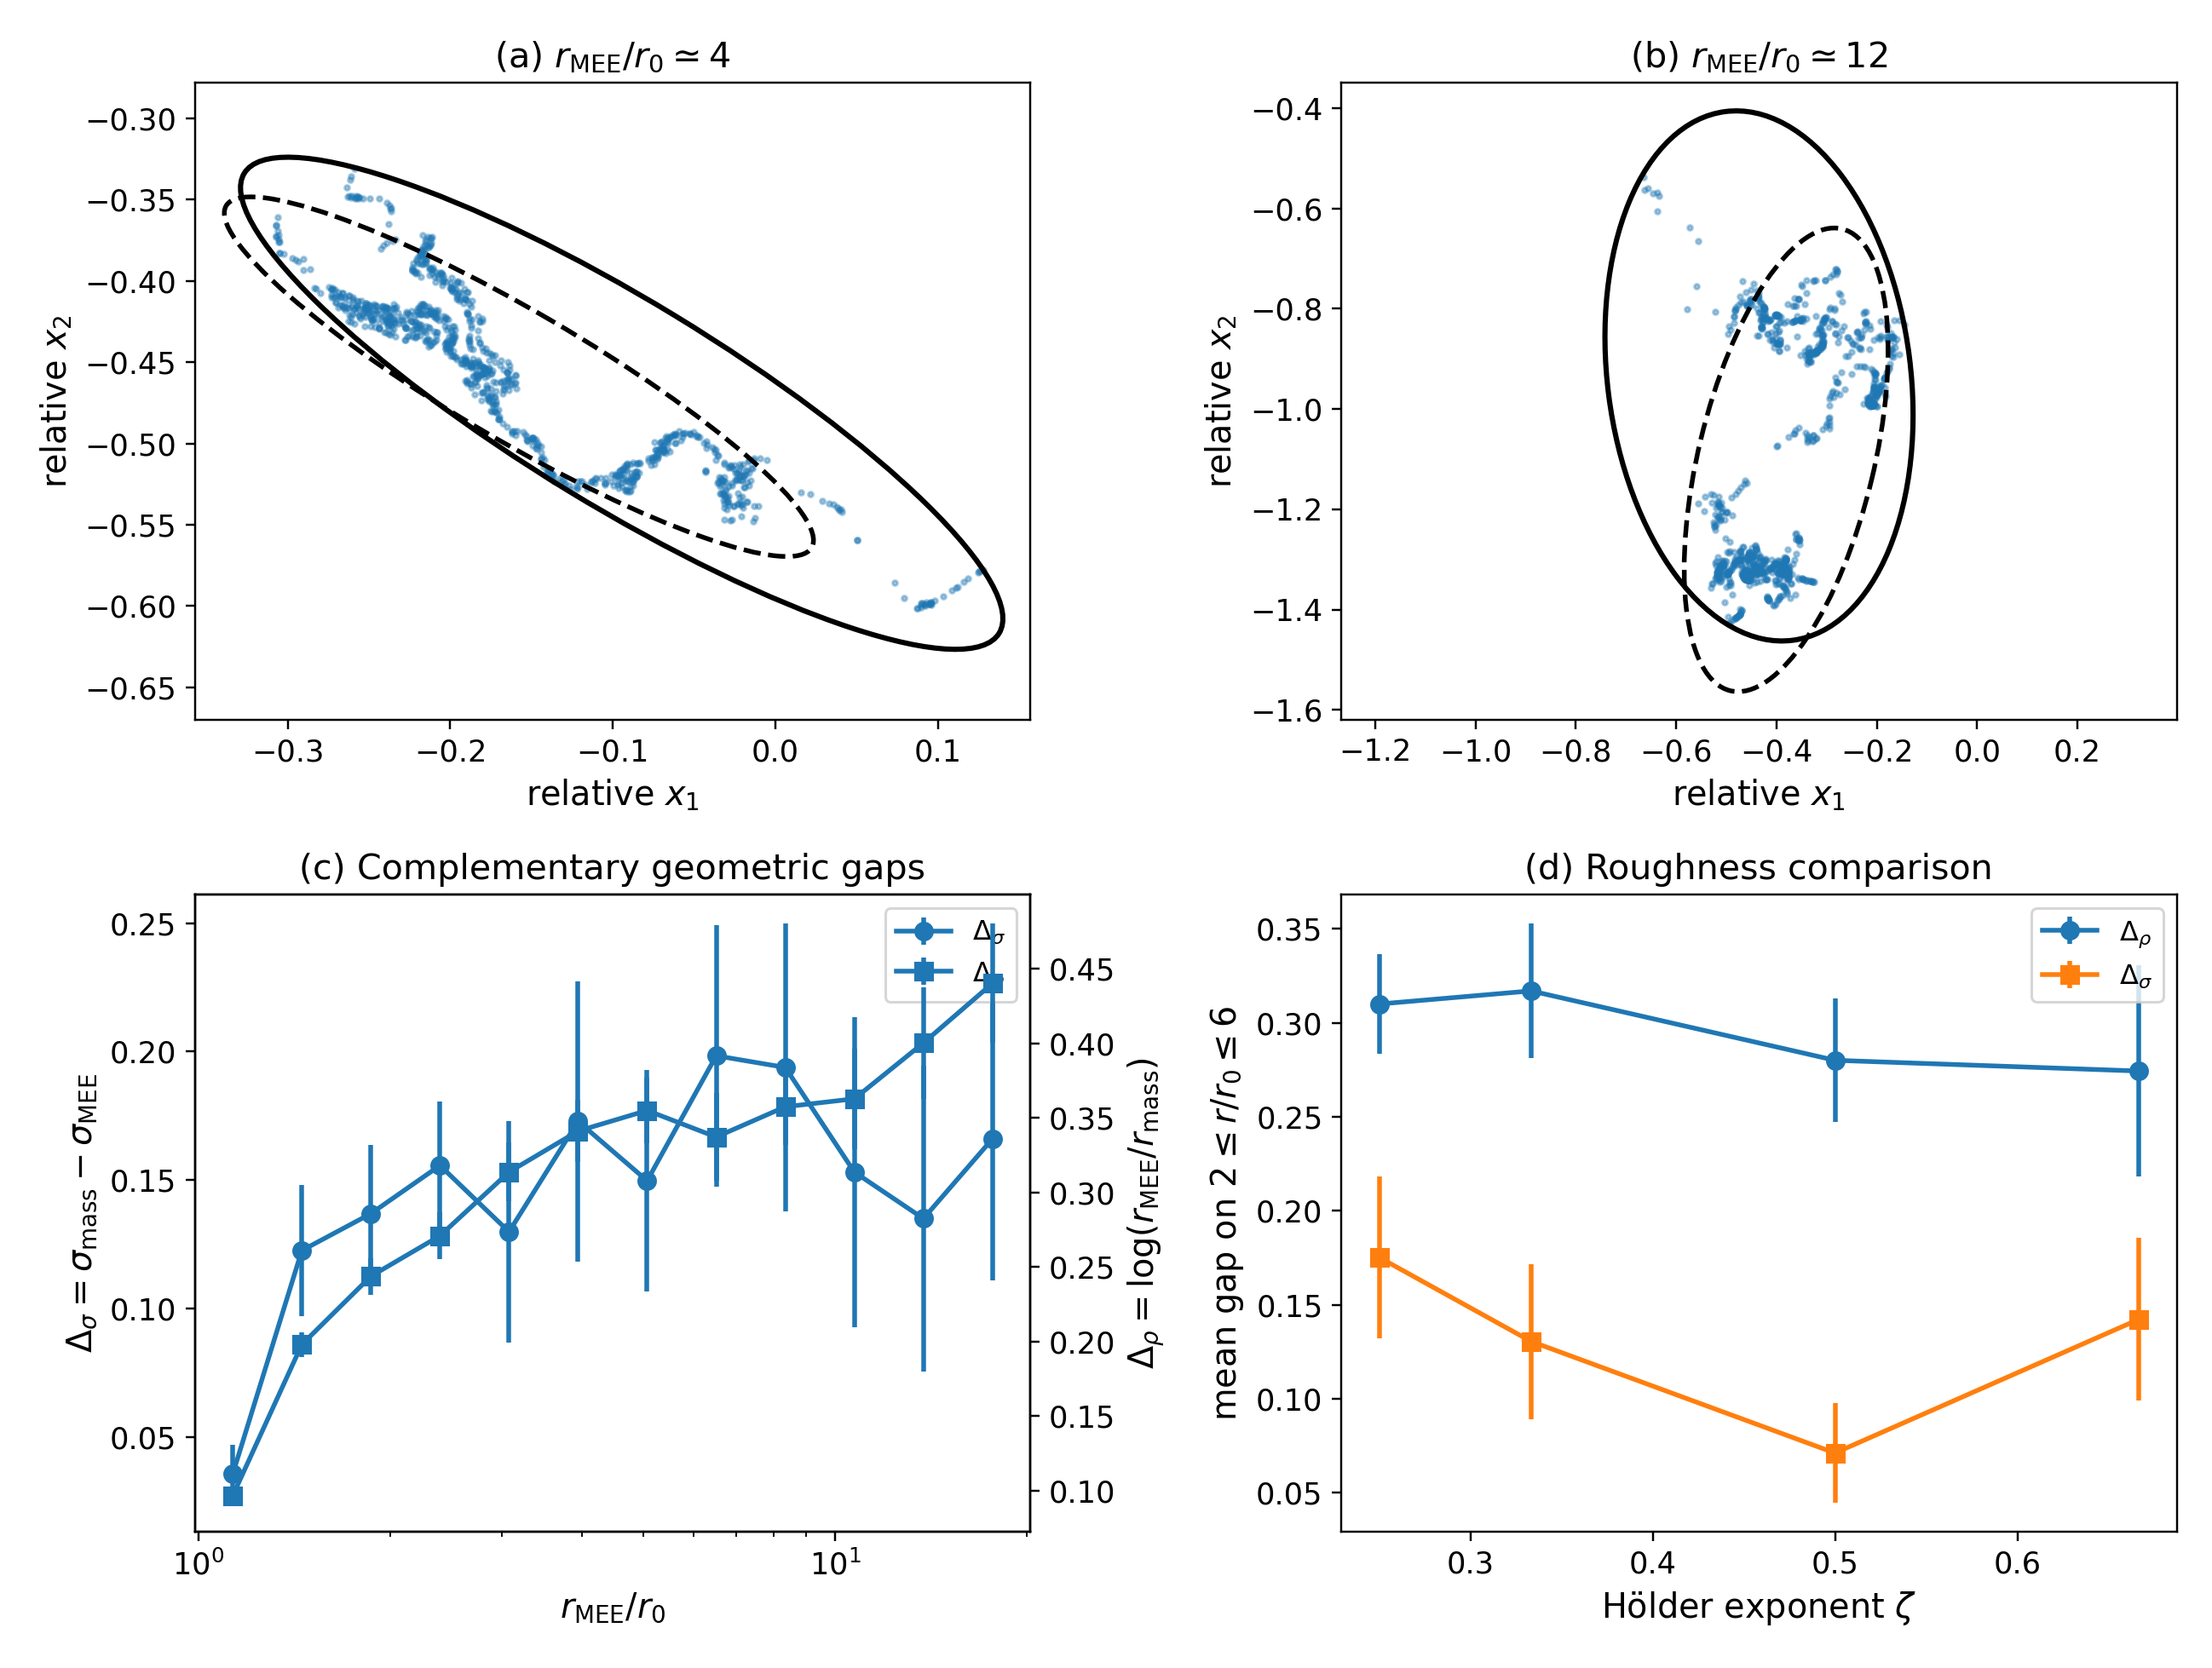

fig04_balance.png


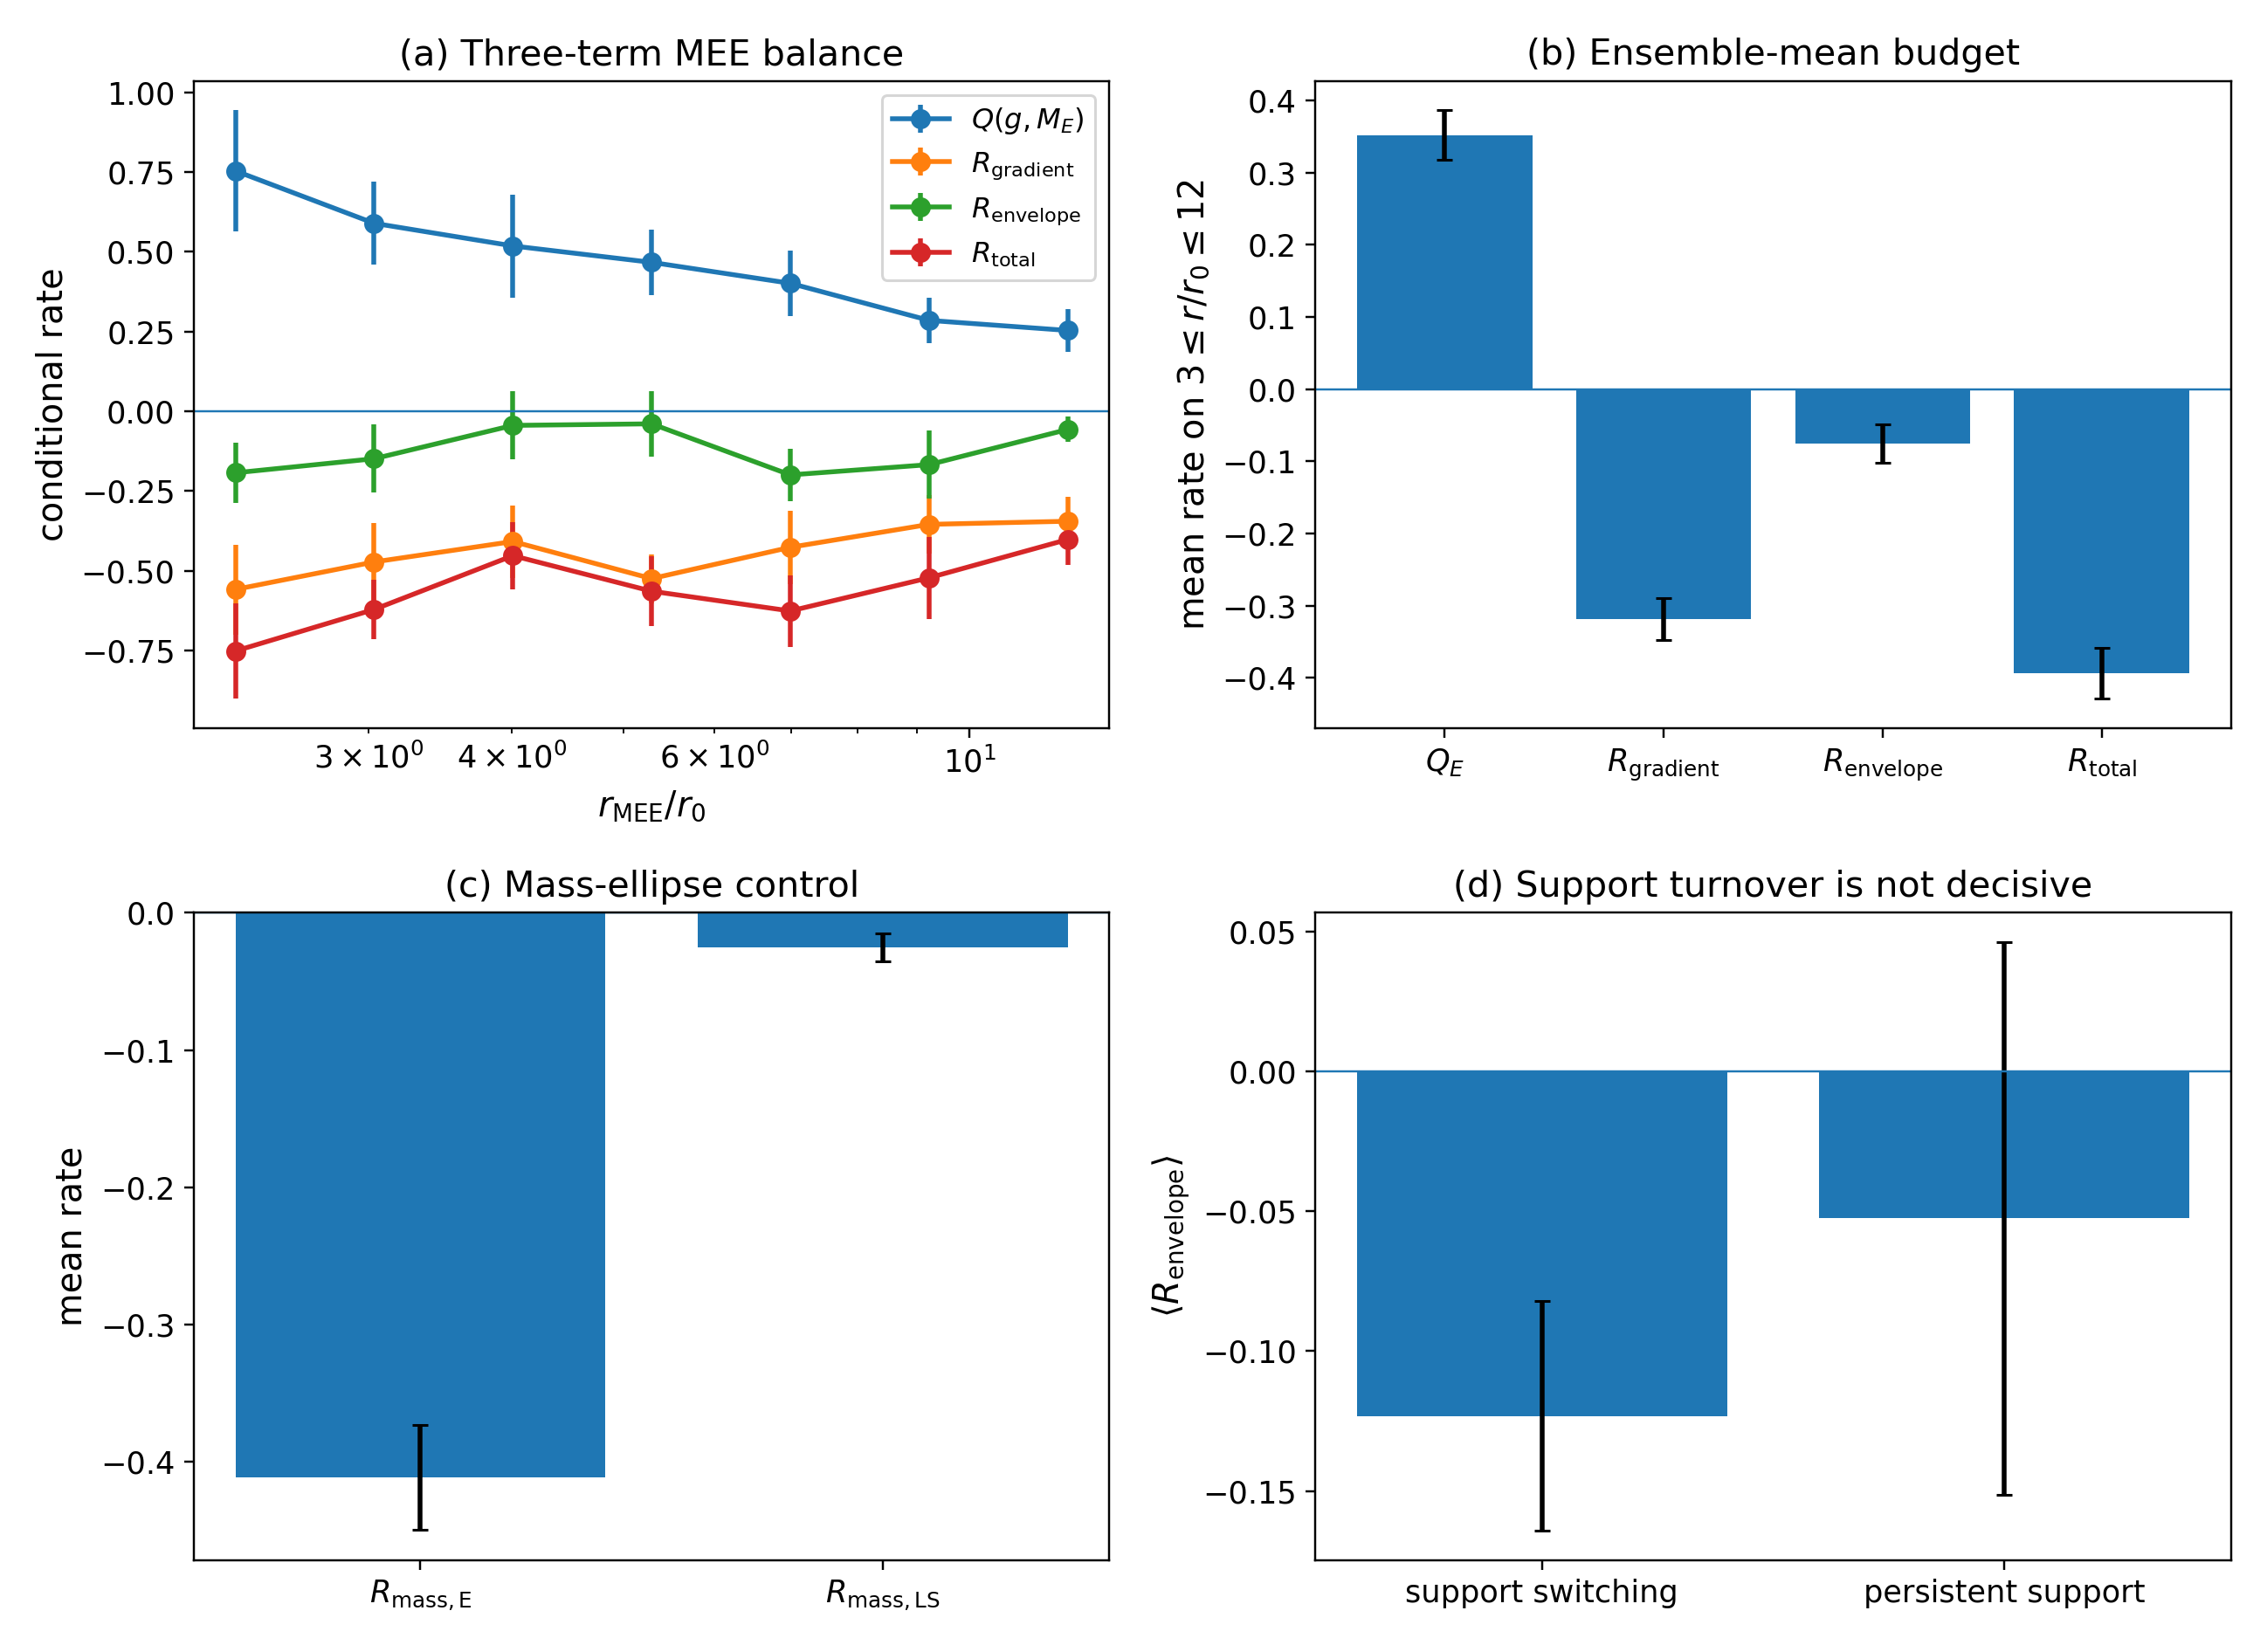

fig05_model.png


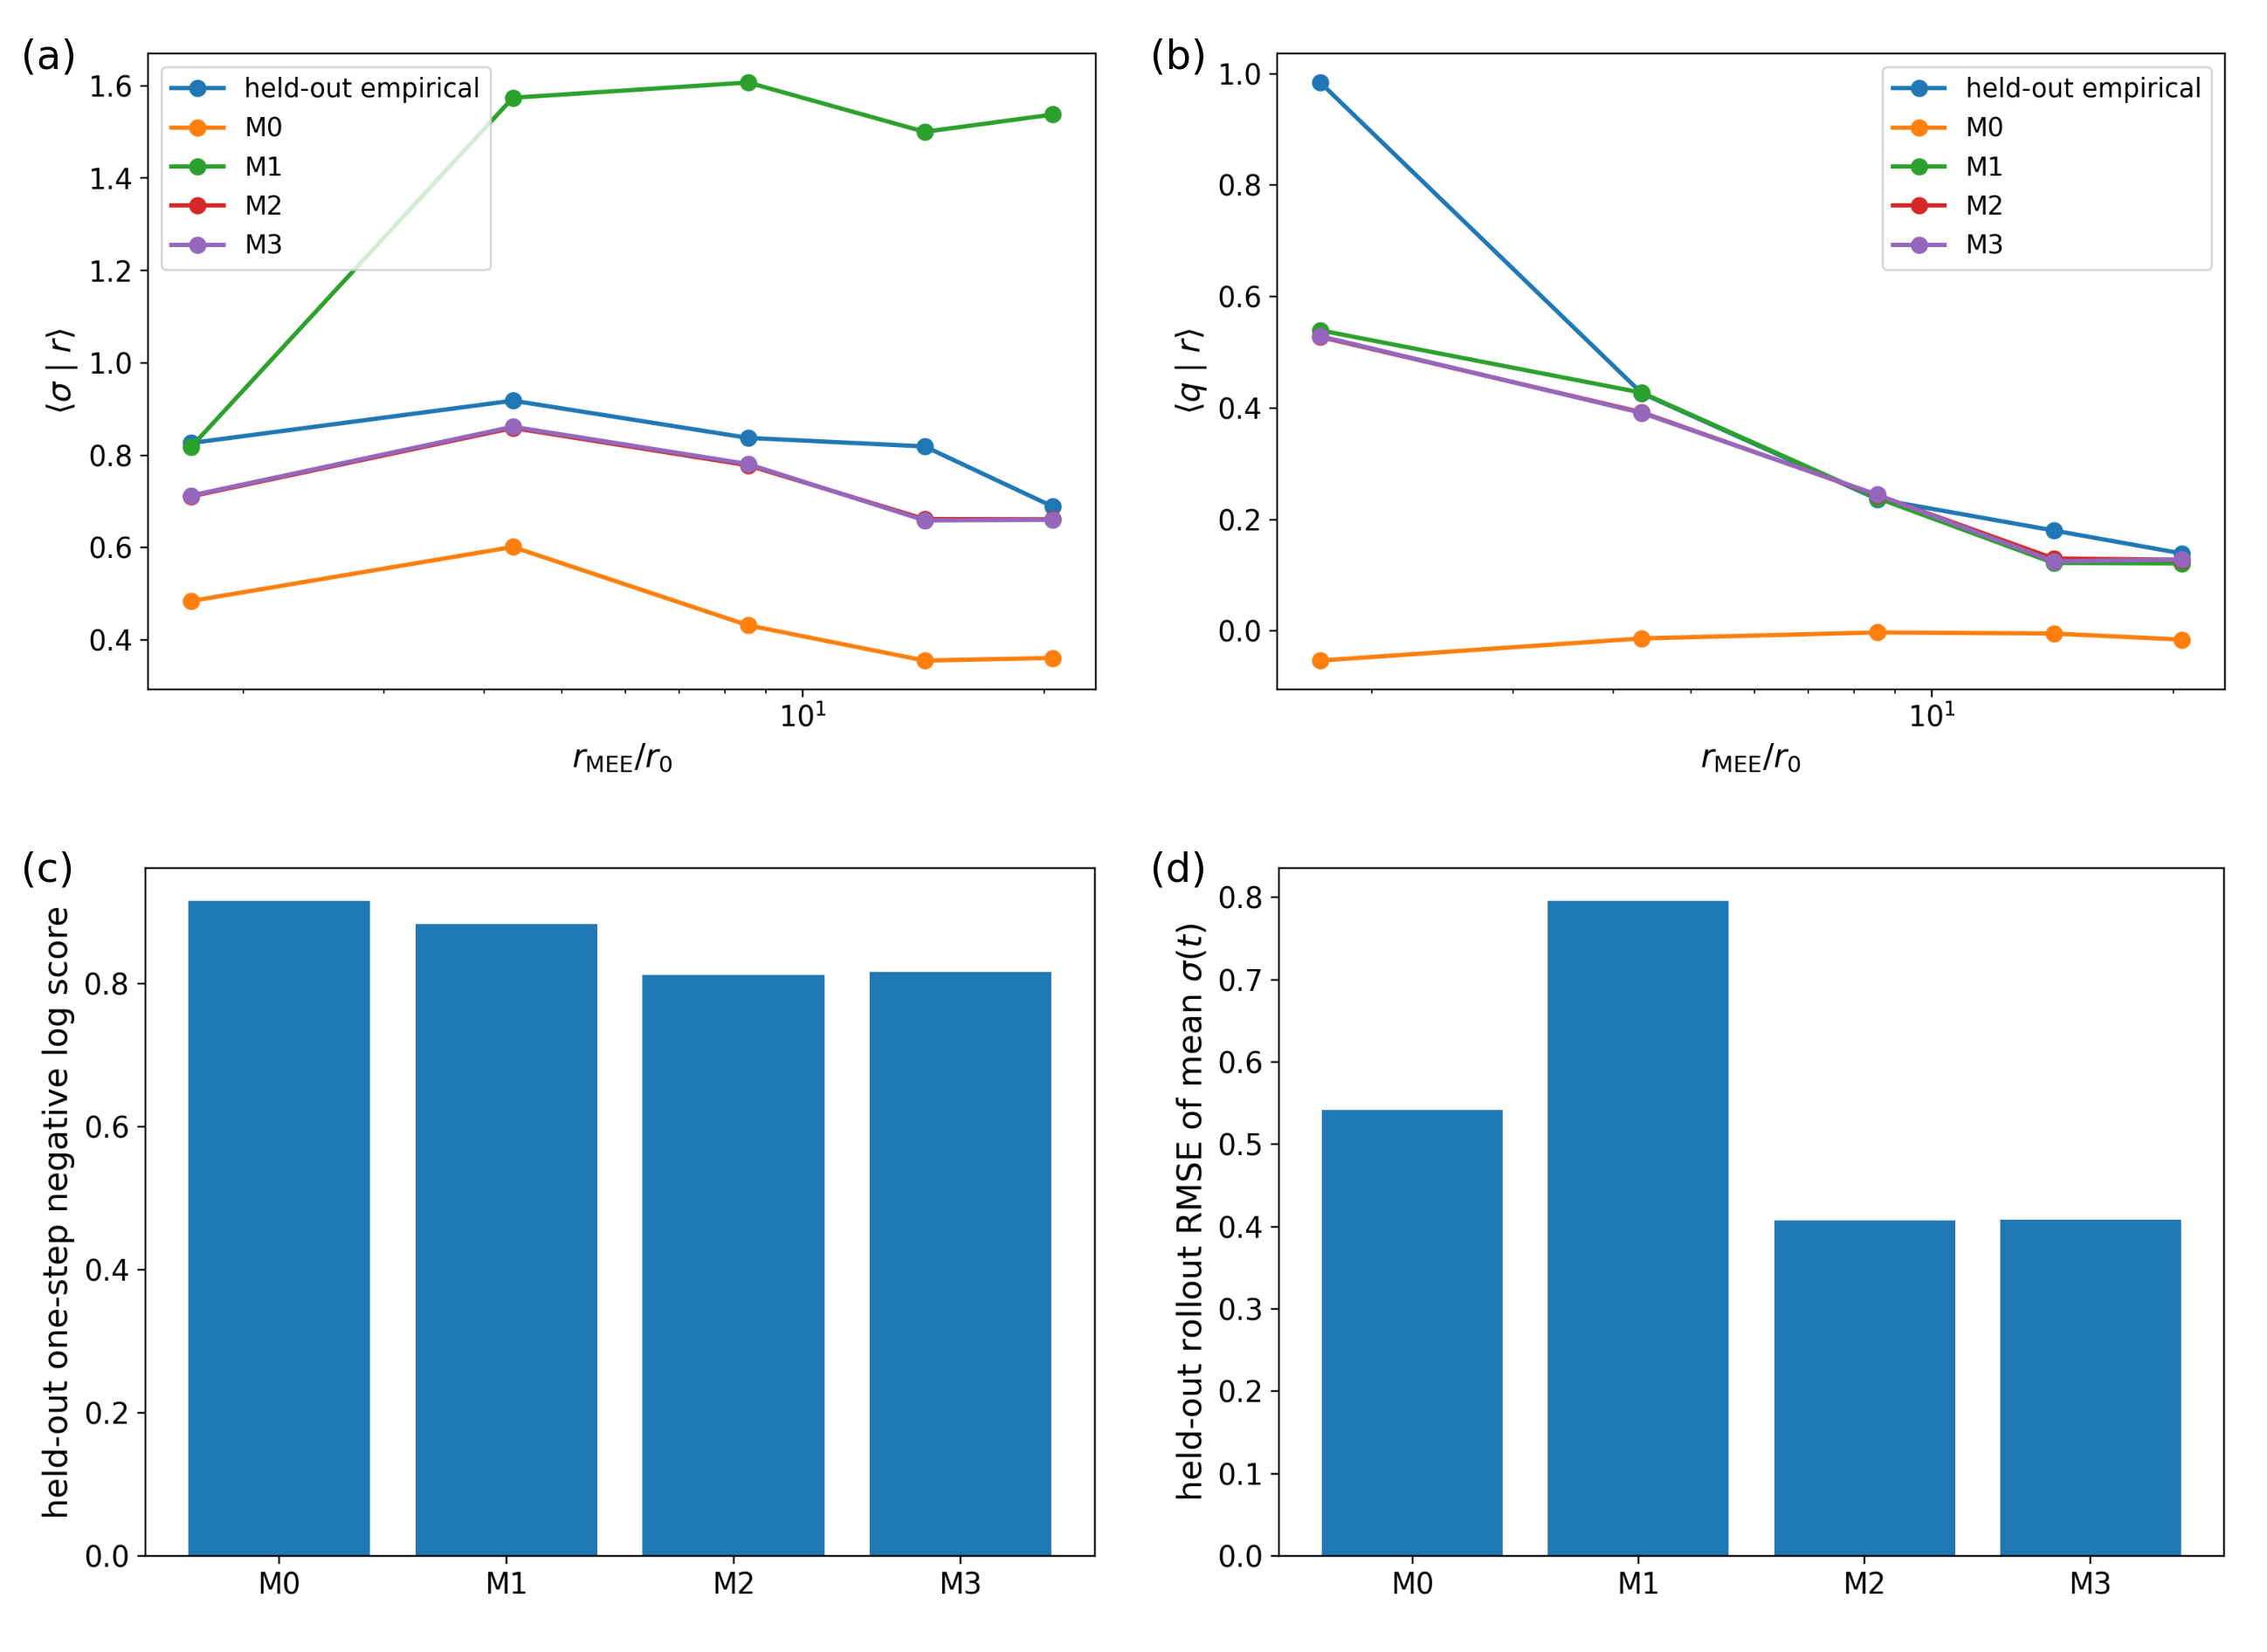

In [4]:
from IPython.display import Image, display
for name in ['fig01_methodology.png','fig02_saturation.png','fig03_bulk_envelope.png','fig04_balance.png','fig05_model.png']:
    print(name)
    display(Image(filename=str(ROOT/'figures/main'/name), width=950))

The manuscript-facing numbers are stored in `data/results/paper_numbers.json`; model scores are stored in the two intrinsic-model summary JSON files.